# SES 2564 — Exploratory Data Analysis

Quick look at the `ses2564.db` database: list tables, inspect the `pmt_dataset` view, and plot the target variable.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys, pathlib

ROOT = pathlib.Path().resolve().parent
DB   = ROOT / 'data' / 'ses2564.db'

con = sqlite3.connect(DB)
print('Connected:', DB)

Connected: /Users/peerachai/Desktop/Academia/Thesis/econ-thesis-pmt/data/ses2564.db


In [2]:
# List all tables and views
objects = pd.read_sql(
    "SELECT type, name FROM sqlite_master WHERE type IN ('table','view') ORDER BY type, name",
    con
)
objects

,type,name
0,table,debt
1,table,expenditure
2,table,household
3,table,housing_assets
4,table,income_sources
5,table,members
6,table,target
7,view,pmt_dataset


In [3]:
# Row counts per table
for _, row in objects[objects.type == 'table'].iterrows():
    n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {row['name']}", con).iloc[0, 0]
    print(f"  {row['name']:20s}: {n:>10,} rows")

  debt                :     46,840 rows
  expenditure         :    421,560 rows
  household           :     46,840 rows
  housing_assets      :     46,840 rows
  income_sources      :    141,743 rows
  members             :    130,670 rows
  target              :     46,840 rows


In [4]:
# Load pmt_dataset view
pmt = pd.read_sql("SELECT * FROM pmt_dataset", con)
print(f'pmt_dataset: {pmt.shape[0]:,} rows × {pmt.shape[1]} cols')
pmt[['household_id','region','area_type','monthly_income_percapita']].head()

pmt_dataset: 46,840 rows × 155 cols


,household_id,region,area_type,monthly_income_percapita
0,1,1,1,10757
1,8,1,1,10750
2,9,1,1,1338
3,11,1,1,29476
4,13,1,1,11971


In [5]:
# Summary stats for target variable
inc = pmt['monthly_income_percapita'].dropna()
inc.describe(percentiles=[.1, .25, .5, .75, .9, .95])

count     46840.000000
mean      10916.035696
std       13969.554397
min     -272377.000000
10%        3259.900000
25%        4701.000000
50%        7417.000000
75%       12484.250000
90%       21223.700000
95%       30368.100000
max      794278.000000
Name: monthly_income_percapita, dtype: float64

/Users/peerachai/Desktop/Academia/Thesis/econ-thesis-pmt/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


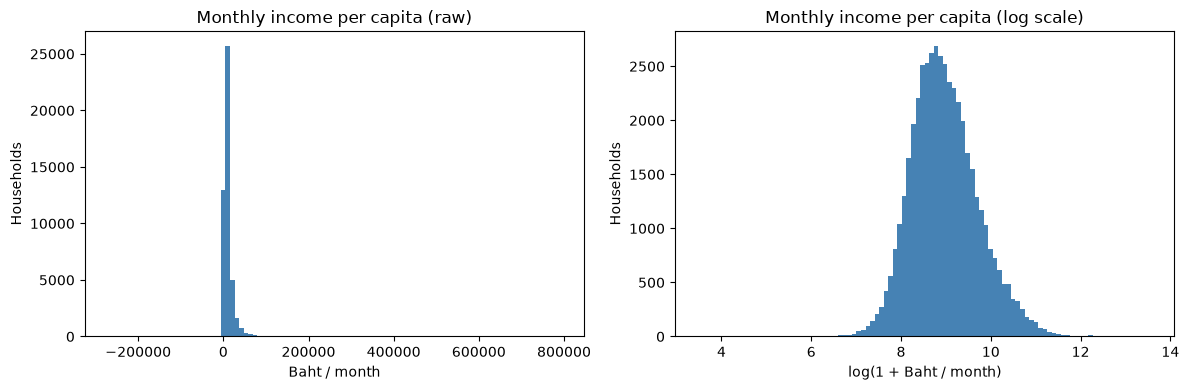

In [6]:
# Histogram of monthly_income_percapita (log scale)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(inc, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Monthly income per capita (raw)')
axes[0].set_xlabel('Baht / month')
axes[0].set_ylabel('Households')

log_inc = np.log1p(inc)
axes[1].hist(log_inc, bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('Monthly income per capita (log scale)')
axes[1].set_xlabel('log(1 + Baht / month)')
axes[1].set_ylabel('Households')

plt.tight_layout()
plt.savefig('../outputs/figures/income_percapita_hist.png', dpi=150)
plt.show()

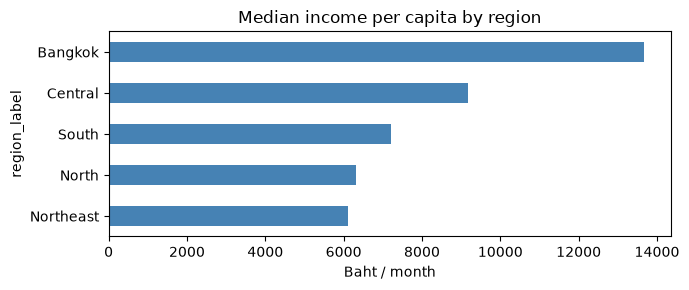

In [7]:
# Income distribution by region
region_map = {1: 'Bangkok', 2: 'Central', 3: 'North', 4: 'Northeast', 5: 'South'}
pmt['region_label'] = pmt['region'].map(region_map)

pmt.groupby('region_label')['monthly_income_percapita'].median().sort_values().plot(
    kind='barh', color='steelblue', figsize=(7, 3), title='Median income per capita by region'
)
plt.xlabel('Baht / month')
plt.tight_layout()
plt.show()

In [8]:
# Income distribution: urban vs rural
area_map = {1: 'Municipal (urban)', 2: 'Non-municipal (rural)'}
pmt['area_label'] = pmt['area_type'].map(area_map)

for label, grp in pmt.groupby('area_label')['monthly_income_percapita']:
    print(f"{label}: median = {grp.median():,.0f} Baht, mean = {grp.mean():,.0f} Baht")

Municipal (urban): median = 8,593 Baht, mean = 12,467 Baht
Non-municipal (rural): median = 6,296 Baht, mean = 8,892 Baht


In [9]:
con.close()
print('Done.')

Done.
